## Hypothesis Testing

Hypothesis testing is a statistical method to evaluate assumptions about a population based on sample data. It allows researchers to make decisions or draw conclusions by testing a null hypothesis $H_0$ against an alternative hypothesis $H_1$.

**Steps in Hypothesis Testing**

**Step 1:** Formulating Hypotheses

**Null Hypothesis $H_0$:** Represents the status quo or no effect. It uses symbols like:
$$H_0 \Rightarrow \leq, \ \geq, \ = $$

**Alternative Hypothesis $H_1$:** Represents a bold claim or effect/difference being tested. It uses symbols like:
$$H_1 \Rightarrow >, \ <, \ \neq$$

**Example: For a new teaching method:**

$H_0$: No improvement in student performance $$\mu \leq 70$$.

$H_1$: Improved student performance $$\mu > 70$$.

**Step 2:** Collecting Sample Data

Take a random sample of size (n) from the population.
Compute the sample mean $\bar{x}$ as the observed statistic.

**Step 3:** Computing the Test Statistic

The test statistic measures how far the sample statistic (e.g., sample mean) deviates from the null hypothesis.
If the Population Variance $\sigma^2$ is Known: Use the Z-statistic:

$$z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}}$$


If the Population Variance $\sigma^2$ is Unknown: Use the T-statistic:
$$t = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}}$$

s: Sample standard deviation (used to estimate $\sigma$).
df = n - 1: Degrees of freedom for the t-test.

**Step 4:** Choosing the Significance Level $\alpha$

The significance level $\alpha$ represents the threshold for rejecting the null hypothesis. It defines the probability of making a Type I error (rejecting $H_0$ when it is true).
Common choices for $\alpha$:
$$ \alpha = 0.05 \ (\text{5%}) \ \text{or} \ \alpha = 0.01 \ (\text{1%})$$
Lower $\alpha$ requires stronger evidence to reject $H_0$.

**Step 5.1:** Applying the Decision Rule
The decision rule depends on the type of test:

**For Z-Statistic:**

Two-Tailed Test:
$$|z| > z_{\frac{\alpha}{2}} \quad \Rightarrow \quad \text{Accept (H_1) or Reject (H_0)}$$
Right-Tailed Test:
$$z > z_{\alpha} \quad \Rightarrow \quad \text{Accept (H_1) or Reject (H_0)}$$
Left-Tailed Test:
$$z < -z_{\alpha} \quad \Rightarrow \quad \text{Accept (H_1) or Reject (H_0)}$$

**For T-Statistic:**

Two-Tailed Test:
$$|t| > t_{n-1,\frac{\alpha}{2}} \quad \Rightarrow \quad \text{Accept (H_1) or Reject (H_0)}$$
Right-Tailed Test:
$$t > t_{n-1,\alpha} \quad \Rightarrow \quad \text{Accept (H_1) or Reject (H_0)}$$
Left-Tailed Test:
$$t < -t_{n-1,\alpha} \quad \Rightarrow \quad \text{Accept (H_1) or Reject (H_0)}$$

**Step 5.2:** Computing the P-Value
The P-value quantifies the probability of observing the test statistic or something more extreme, assuming $H_0$ is true.

For Two-Tailed Test:
$$p \text{ value} = 2 \cdot (1.0 - cdf(\text{test statistic}))$$
For One-Tailed Test:
$$p \text{ value} = 1.0 - cdf(\text{test statistic})$$
Decision Rule:
Reject (H_0) if $$p \leq \alpha$$.
Fail to Reject (H_0) if $$p > \alpha$$.

**Problem Statement: A restaurant owner asserts that the average total bill for customers is ₹20. To validate this assertion, we will conduct a hypothesis test using a significance level of 0.05 and a population standard deviation of ₹8.34. A random sample of customer bills from the "tips" dataset will be analyzed.**

- **Null Hypothesis ($H_0$)**: The average total bill for customers is ₹20.  
  $$H_0: \mu = 20$$  

- **Alternative Hypothesis ($H_a$)**: The average total bill for customers is **not** ₹20.  
  $$H_a: \mu \neq 20$$  

This is a **two-tailed test** because we are testing for a deviation from ₹20 in either direction.


Z-Score: 1.3134833513313338
P-Value: 0.18902012731164852
Critical Z-Value: 1.959963984540054
Decision: Fail to Reject Null Hypothesis
Decision based on P-Value: Fail to Reject Null Hypothesis


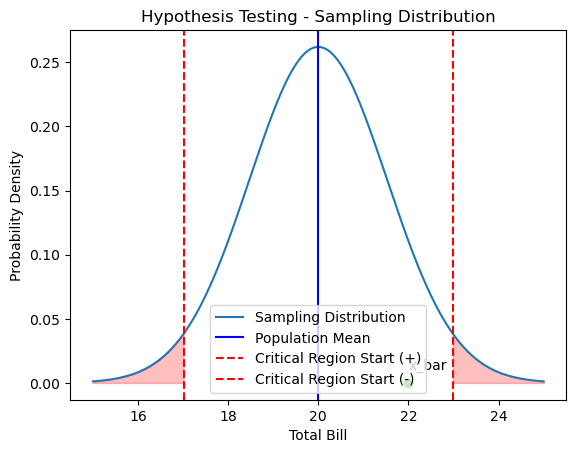

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Define the hypothesis
pop_mean = 20  # Population mean
pop_std = 8.34  # Population standard deviation
sample_size = 30  # Sample size
sample_mean = 22  # Hypothetical sample mean (replace with actual calculation)

# Step 2: Calculate sampling standard deviation
sampling_std = pop_std / np.sqrt(sample_size)

# Step 3: Calculate Z-score
z_score = (sample_mean - pop_mean) / sampling_std
p_value = 2 * (1 - stats.norm.cdf(np.abs(z_score)))  # Two-tailed test

# Step 4: Determine critical Z-value
alpha = 0.05  # Significance level
z_critical = stats.norm.ppf(1 - alpha / 2)  # Critical Z-value for two-tailed test

# Step 5: Decision
print(f"Z-Score: {z_score}")
print(f"P-Value: {p_value}")
print(f"Critical Z-Value: {z_critical}")

if np.abs(z_score) > z_critical:
    print("Decision: Reject Null Hypothesis")
else:
    print("Decision: Fail to Reject Null Hypothesis")

if p_value < alpha:
    print("Decision based on P-Value: Reject Null Hypothesis")
else:
    print("Decision based on P-Value: Fail to Reject Null Hypothesis")

# Step 6: Plot the sampling distribution
x_min, x_max = 15, 25
x = np.linspace(x_min, x_max, 1000)
y = stats.norm.pdf(x, loc=pop_mean, scale=sampling_std)

plt.plot(x, y, label="Sampling Distribution")
plt.axvline(x=pop_mean, color='blue', linestyle='-', label="Population Mean")
plt.axvline(x=pop_mean + z_critical * sampling_std, color='red', linestyle='--', label="Critical Region Start (+)")
plt.axvline(x=pop_mean - z_critical * sampling_std, color='red', linestyle='--', label="Critical Region Start (-)")
plt.scatter(x=sample_mean, y = 0, color='green')
plt.annotate('x_bar', (sample_mean, 0.01))
plt.fill_between(x[x > pop_mean + z_critical * sampling_std], y[x > pop_mean + z_critical * sampling_std], color='red', alpha=0.25)
plt.fill_between(x[x < pop_mean - z_critical * sampling_std], y[x < pop_mean - z_critical * sampling_std], color='red', alpha=0.25)
plt.legend(loc = 'best')
plt.title("Hypothesis Testing - Sampling Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.show()

**Problem Statement: A restaurant owner asserts that the average total bill for customers is less than or equal to ₹20. To validate this assertion, we will conduct a hypothesis test using a significance level of 0.05 and a population standard deviation of ₹8.34. A random sample of customer bills from the "tips" dataset will be analyzed.**

### Hypotheses for the Problem Statement:

1. **Null Hypothesis ($H_0$)**: The average total bill for customers is less than or equal to ₹20.
   $$H_0: \mu \leq 20$$

2. **Alternative Hypothesis ($H_a$)**: The average total bill for customers is greater than ₹20.
   $$H_a: \mu > 20$$

This is a **one-tailed test**, as the alternative hypothesis specifies "greater than ₹20."

Sample Mean: 22
Sampling Standard Deviation: 1.5226687098643616
Z-Score: 1.3134833513313338
P-Value: 0.09451006365582426
Critical Z-Value: 1.6448536269514722
Decision: Fail to Reject Null Hypothesis
Decision based on P-Value: Fail to Reject Null Hypothesis


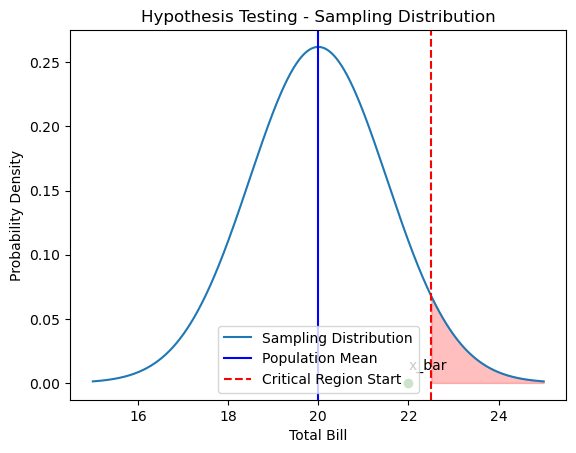

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Define the hypothesis
pop_mean = 20  # Population mean (claimed average)
pop_std = 8.34  # Population standard deviation
sample_size = 30  # Sample size
sample_mean = 22  # Hypothetical sample mean (replace with actual data)

# Step 2: Calculate sampling standard deviation
sampling_std = pop_std / np.sqrt(sample_size)

# Step 3: Calculate Z-score
z_score = (sample_mean - pop_mean) / sampling_std

# Step 4: Determine critical Z-value
alpha = 0.05  # Significance level
z_critical = stats.norm.ppf(1 - alpha)  # Critical Z-value for a one-tailed test

# Step 5: Compute p-value
p_value = 1 - stats.norm.cdf(z_score)  # Right-tailed test

# Step 6: Decision
print(f"Sample Mean: {sample_mean}")
print(f"Sampling Standard Deviation: {sampling_std}")
print(f"Z-Score: {z_score}")
print(f"P-Value: {p_value}")
print(f"Critical Z-Value: {z_critical}")

if z_score > z_critical:
    print("Decision: Reject Null Hypothesis")
else:
    print("Decision: Fail to Reject Null Hypothesis")

if p_value < alpha:
    print("Decision based on P-Value: Reject Null Hypothesis")
else:
    print("Decision based on P-Value: Fail to Reject Null Hypothesis")

# Step 7: Plot Sampling Distribution
x_min, x_max = 15, 25
x = np.linspace(x_min, x_max, 1000)
y = stats.norm.pdf(x, loc=pop_mean, scale=sampling_std)

plt.plot(x, y, label="Sampling Distribution")
plt.axvline(x=pop_mean, color='blue', linestyle='-', label="Population Mean")
plt.axvline(x=pop_mean + z_critical * sampling_std, color='red', linestyle='--', label="Critical Region Start")
plt.scatter(x=sample_mean, y = 0, color='green')
plt.annotate('x_bar', (sample_mean, 0.01))
plt.fill_between(x[x > pop_mean + z_critical * sampling_std], y[x > pop_mean + z_critical * sampling_std], color='red', alpha=0.25)
plt.legend(loc='best')
plt.title("Hypothesis Testing - Sampling Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.show()

**Problem Statement: A restaurant owner asserts that the average total bill for customers is greater than ₹20. To validate this claim, we will conduct a hypothesis test using a significance level of 0.05 and a population standard deviation of ₹8.34. A random sample of customer bills from the "tips" dataset will be analyzed.**

### Hypotheses for the Problem Statement:

1. **Null Hypothesis ($H_0$)**: The average total bill for customers is less than or equal to ₹20.  
   $$H_0: \mu \leq 20$$  

2. **Alternative Hypothesis ($H_1$)**: The average total bill for customers is greater than ₹20.  
   $$H_1: \mu > 20$$  

This is a **one-tailed test** because the claim specifies "greater than ₹20" in the alternative hypothesis.


Sample Mean: 22
Sampling Standard Deviation: 1.5226687098643616
Z-Score: 1.3134833513313338
P-Value: 0.09451006365582426
Critical Z-Value: 1.6448536269514722
Decision: Fail to Reject Null Hypothesis (H0)
Decision based on P-Value: Fail to Reject Null Hypothesis (H0)


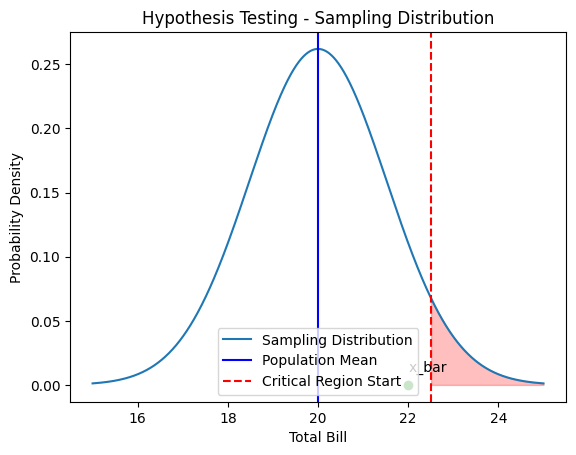

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Define the hypothesis
pop_mean = 20  # Population mean (claimed average)
pop_std = 8.34  # Population standard deviation
sample_size = 30  # Sample size
sample_mean = 22  # Hypothetical sample mean (replace with actual calculation)

# Step 2: Calculate sampling standard deviation
sampling_std = pop_std / np.sqrt(sample_size)

# Step 3: Calculate Z-score
z_score = (sample_mean - pop_mean) / sampling_std

# Step 4: Determine critical Z-value
alpha = 0.05  # Significance level
z_critical = stats.norm.ppf(1 - alpha)  # Critical Z-value for one-tailed test

# Step 5: Compute p-value
p_value = 1 - stats.norm.cdf(z_score)  # Right-tailed test

# Step 6: Decision
print(f"Sample Mean: {sample_mean}")
print(f"Sampling Standard Deviation: {sampling_std}")
print(f"Z-Score: {z_score}")
print(f"P-Value: {p_value}")
print(f"Critical Z-Value: {z_critical}")

if z_score > z_critical:
    print("Decision: Reject Null Hypothesis (H0)")
else:
    print("Decision: Fail to Reject Null Hypothesis (H0)")

if p_value < alpha:
    print("Decision based on P-Value: Reject Null Hypothesis (H0)")
else:
    print("Decision based on P-Value: Fail to Reject Null Hypothesis (H0)")

# Step 7: Plot Sampling Distribution
x_min, x_max = 15, 25
x = np.linspace(x_min, x_max, 1000)
y = stats.norm.pdf(x, loc=pop_mean, scale=sampling_std)

plt.plot(x, y, label="Sampling Distribution")
plt.axvline(x=pop_mean, color='blue', linestyle='-', label="Population Mean")
plt.axvline(x=pop_mean + z_critical * sampling_std, color='red', linestyle='--', label="Critical Region Start")
plt.scatter(x=sample_mean, y = 0, color='green')
plt.annotate('x_bar', (sample_mean, 0.01))
plt.fill_between(x[x > pop_mean + z_critical * sampling_std], y[x > pop_mean + z_critical * sampling_std], color='red', alpha=0.25)
plt.legend(loc='best')
plt.title("Hypothesis Testing - Sampling Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.show()

**Problem Statement: A restaurant owner claims that the average total bill for customers is less than ₹20. To validate this claim, we will perform a hypothesis test using a significance level of 0.05 and a population standard deviation of ₹8.34. A random sample of customer bills from the "tips" dataset will be analyzed.**

### Hypotheses for the Problem Statement:

1. **Null Hypothesis ($H_0$)**: The average total bill for customers is greater than or equal to ₹20.  
   $$H_0: \mu \geq 20$$  

2. **Alternative Hypothesis ($H_a$)**: The average total bill for customers is less than ₹20.  
   $$H_a: \mu < 20$$  

This is a **one-tailed test** because the claim specifies "less than ₹20" in the alternative hypothesis.

Sample Mean: 22
Sampling Standard Deviation: 1.5226687098643616
Z-Score: 1.3134833513313338
P-Value: 0.9054899363441757
Critical Z-Value: -1.6448536269514729
Decision: Fail to Reject Null Hypothesis (H0)
Decision based on P-Value: Fail to Reject Null Hypothesis (H0)


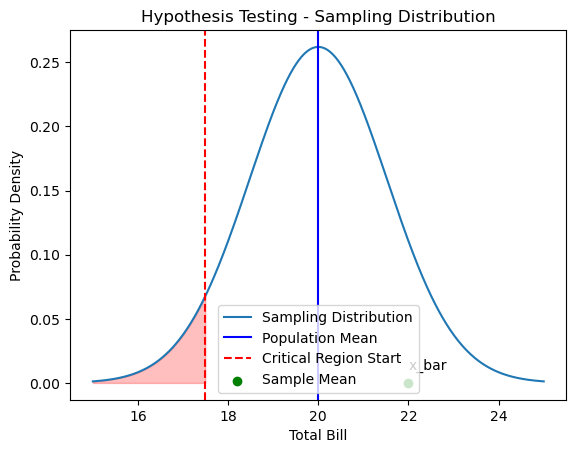

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Define the hypothesis
pop_mean = 20  # Population mean (claimed average)
pop_std = 8.34  # Population standard deviation
sample_size = 30  # Sample size
sample_mean = 22  # Hypothetical sample mean (replace with actual calculation)

# Step 2: Calculate sampling standard deviation
sampling_std = pop_std / np.sqrt(sample_size)

# Step 3: Calculate Z-score
z_score = (sample_mean - pop_mean) / sampling_std

# Step 4: Determine critical Z-value
alpha = 0.05  # Significance level
z_critical = stats.norm.ppf(alpha)  # Critical Z-value for one-tailed test (left-tailed)

# Step 5: Compute p-value
p_value = stats.norm.cdf(z_score)  # Left-tailed test

# Step 6: Decision
print(f"Sample Mean: {sample_mean}")
print(f"Sampling Standard Deviation: {sampling_std}")
print(f"Z-Score: {z_score}")
print(f"P-Value: {p_value}")
print(f"Critical Z-Value: {z_critical}")

if z_score < z_critical:
    print("Decision: Reject Null Hypothesis (H0)")
else:
    print("Decision: Fail to Reject Null Hypothesis (H0)")

if p_value < alpha:
    print("Decision based on P-Value: Reject Null Hypothesis (H0)")
else:
    print("Decision based on P-Value: Fail to Reject Null Hypothesis (H0)")

# Step 7: Plot Sampling Distribution
x_min, x_max = 15, 25
x = np.linspace(x_min, x_max, 1000)
y = stats.norm.pdf(x, loc=pop_mean, scale=sampling_std)

plt.plot(x, y, label="Sampling Distribution")
plt.axvline(x=pop_mean, color='blue', linestyle='-', label="Population Mean")
plt.axvline(x=pop_mean + z_critical * sampling_std, color='red', linestyle='--', label="Critical Region Start")
plt.scatter(x=sample_mean, y = 0, color='green', label="Sample Mean")
plt.annotate('x_bar', (sample_mean, 0.01))
plt.fill_between(x[x < pop_mean + z_critical * sampling_std], y[x < pop_mean + z_critical * sampling_std], color='red', alpha=0.25)
plt.legend(loc='best')
plt.title("Hypothesis Testing - Sampling Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.show()

**Problem Statement: A restaurant owner claims that the average total bill for customers is ₹20. To validate this claim, we will perform a hypothesis test using a significance level of 0.05. A random sample of customer bills from the "tips" dataset will be analyzed.**

Here is the Python code to validate the restaurant owner's claim using a **t-test** when the population standard deviation is unknown:

### Step-by-Step Hypothesis Test
1. **Null Hypothesis ($H_0$)**: The average total bill for customers is ₹20.  
   $$H_0: \mu = 20$$  
2. **Alternative Hypothesis ($H_a$)**: The average total bill for customers is **not** ₹20.  
   $$H_a: \mu \neq 20$$  

Since the population standard deviation is unknown, we use the **t-test** with the sample standard deviation.

Sample Mean: 20.350000000000005
Sample Standard Deviation: 1.2127910244413578
T-Score: 1.5806754112079124
P-Value: 0.1247990490756512
Critical T-Value: 2.045229642132703
Decision: Fail to Reject Null Hypothesis
Decision based on P-Value: Fail to Reject Null Hypothesis


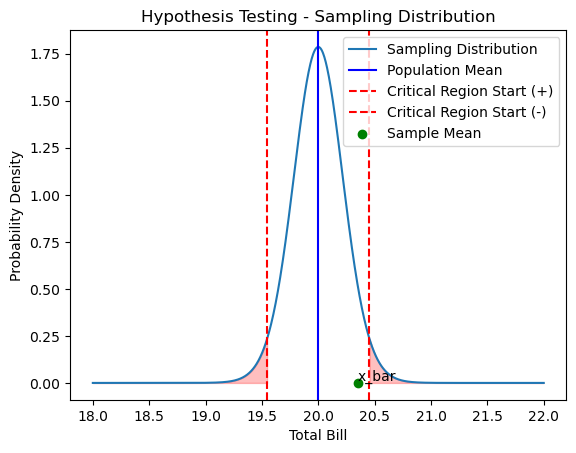

In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Define the hypothesis
pop_mean = 20  # Population mean (claimed average)
sample_size = 30  # Sample size
sample = np.array([21, 19, 20.5, 22, 18, 19.5, 20, 21.5, 18.5, 22, 21, 19, 20, 21.8, 19.2,
                   20.3, 21.2, 18.7, 19.8, 21.1, 20.6, 22.3, 21.4, 20.1, 19.9, 18.5, 22.1,
                   19.7, 20.2, 21.6])  # Example sample data (replace with actual data)

# Step 2: Calculate sample statistics
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # Sample standard deviation (unbiased)

# Step 3: Calculate t-score
t_score = (sample_mean - pop_mean) / (sample_std / np.sqrt(sample_size))

# Step 4: Determine critical t-value
alpha = 0.05  # Significance level
df = sample_size - 1  # Degrees of freedom
t_critical = stats.t.ppf(1 - alpha / 2, df)  # Two-tailed test

# Step 5: Compute p-value
p_value = 2 * (1 - stats.t.cdf(np.abs(t_score), df))  # Two-tailed test

# Step 6: Decision
print(f"Sample Mean: {sample_mean}")
print(f"Sample Standard Deviation: {sample_std}")
print(f"T-Score: {t_score}")
print(f"P-Value: {p_value}")
print(f"Critical T-Value: {t_critical}")

if np.abs(t_score) > t_critical:
    print("Decision: Reject Null Hypothesis")
else:
    print("Decision: Fail to Reject Null Hypothesis")

if p_value < alpha:
    print("Decision based on P-Value: Reject Null Hypothesis")
else:
    print("Decision based on P-Value: Fail to Reject Null Hypothesis")

# Step 7: Plot Sampling Distribution
x_min, x_max = 18, 22
x = np.linspace(x_min, x_max, 1000)
y = stats.t.pdf(x, loc=pop_mean, scale=sample_std / np.sqrt(sample_size), df=df)

plt.plot(x, y, label="Sampling Distribution")
plt.axvline(x=pop_mean, color='blue', linestyle='-', label="Population Mean")
plt.axvline(x=pop_mean + t_critical * (sample_std / np.sqrt(sample_size)), color='red', linestyle='--', label="Critical Region Start (+)")
plt.axvline(x=pop_mean - t_critical * (sample_std / np.sqrt(sample_size)), color='red', linestyle='--', label="Critical Region Start (-)")
plt.scatter(x=sample_mean, y=0, color='green', label="Sample Mean")
plt.annotate('x_bar', (sample_mean, 0.01))
plt.fill_between(x[x > pop_mean + t_critical * (sample_std / np.sqrt(sample_size))],
                 y[x > pop_mean + t_critical * (sample_std / np.sqrt(sample_size))], color='red', alpha=0.25)
plt.fill_between(x[x < pop_mean - t_critical * (sample_std / np.sqrt(sample_size))],
                 y[x < pop_mean - t_critical * (sample_std / np.sqrt(sample_size))], color='red', alpha=0.25)
plt.legend(loc='best')
plt.title("Hypothesis Testing - Sampling Distribution")
plt.xlabel("Total Bill")
plt.ylabel("Probability Density")
plt.show()

#### Alternate way
### Hypotheses for the Problem Statement:

**Problem Statement**: A restaurant owner claims that the average total bill for customers is ₹20. To validate this claim, we will perform a hypothesis test using a significance level of 0.05. A random sample of customer bills from the "tips" dataset will be analyzed.

**Hypotheses**:

1. **Null Hypothesis ($H_0$)**: The average total bill for customers is ₹20.  
   $$H_0: \mu = 20$$  

2. **Alternative Hypothesis ($H_a$)**: The average total bill for customers is not ₹20.  
   $$H_a: \mu \neq 20$$  

This setup represents a **two-tailed test**, as we are testing for any deviation (either higher or lower) from the claimed average bill of ₹20.

In [5]:
import numpy as np
import scipy.stats as stats

# Step 1: Define the sample data
sample = np.array([21, 19, 20.5, 22, 18, 19.5, 20, 21.5, 18.5, 22, 21, 19, 20, 21.8, 19.2,
                   20.3, 21.2, 18.7, 19.8, 21.1, 20.6, 22.3, 21.4, 20.1, 19.9, 18.5, 22.1,
                   19.7, 20.2, 21.6])  # Replace with your actual sample data

# Step 2: Define the population mean (null hypothesis mean)
pop_mean = 20  # Null hypothesis claimed mean

# Step 3: Perform a one-sample t-test
t_statistic, p_value = stats.ttest_1samp(sample, pop_mean)

# Step 4: Output the results
print(f"T-Statistic: {t_statistic}")
print(f"P-Value: {p_value}")

# Step 5: Decision based on p-value
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Decision: Reject Null Hypothesis (H0)")
else:
    print("Decision: Fail to Reject Null Hypothesis (H0)")

T-Statistic: 1.5806754112079124
P-Value: 0.12479904907565118
Decision: Fail to Reject Null Hypothesis (H0)


**Problem Statement: A restaurant owner claims that the proportion of males and females among customers is **equally likely**. To validate this claim, we will conduct a **hypothesis test** using a random sample drawn from the "tips" dataset. We'll use a significance level of 0.05.**

### Hypotheses:
1. **Null Hypothesis ($H_0$)**: The proportion of males and females in the population is equal.  
   $$H_0: p = 0.5$$  

2. **Alternative Hypothesis ($H_a$)**: The proportion of males and females in the population is **not equal**.  
   $$H_a: p \neq 0.5$$  

This is a **two-tailed test**, as we are checking for any deviation from equality in proportions.

Sample Proportion of Males: 0.62
Z-Score: 1.697056274847714
P-Value: 0.08968602177036455
Critical Z-Value: ±1.959963984540054
Decision: Fail to Reject Null Hypothesis (H0)


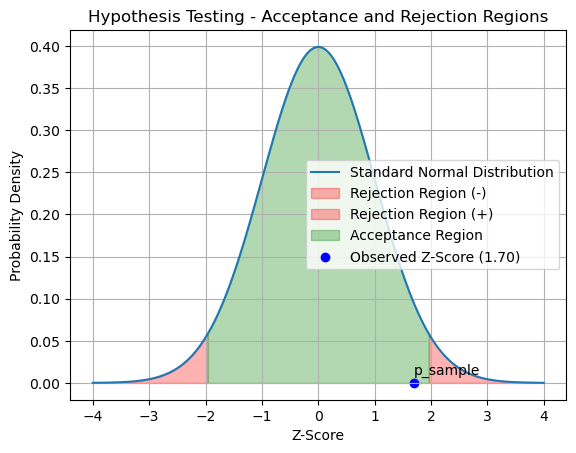

In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load the tips dataset (Replace with actual loading method if needed)
from seaborn import load_dataset
tips = load_dataset('tips')

# Step 1: Consider the "sex" column as the population
population_sex = tips['sex']

# Step 2: Draw a random sample from the population
sample_size = 50  # Define sample size
sample_sex = population_sex.sample(n=sample_size, random_state=42)

# Step 3: Calculate the observed proportion of males in the sample
male_count = (sample_sex == 'Male').sum()
sample_proportion = male_count / sample_size

# Step 4: Define null hypothesis proportion
null_proportion = 0.5  # Proportion under the null hypothesis

# Step 5: Perform a one-sample proportion Z-test
# Calculate the Z-score
sampling_std = np.sqrt(null_proportion * (1 - null_proportion) / sample_size)
z_score = (sample_proportion - null_proportion) / sampling_std

# Calculate the critical Z-value for a two-tailed test
alpha = 0.05  # Significance level
z_critical = stats.norm.ppf(1 - alpha / 2)  # Two-tailed test critical Z-value

# Calculate the p-value for a two-tailed test
p_value = 2 * (1 - stats.norm.cdf(np.abs(z_score)))  # Two-tailed test

# Step 6: Decision and Print Results
print(f"Sample Proportion of Males: {sample_proportion}")
print(f"Z-Score: {z_score}")
print(f"P-Value: {p_value}")
print(f"Critical Z-Value: ±{z_critical}")

if np.abs(z_score) > z_critical:
    print("Decision: Reject Null Hypothesis (H0)")
else:
    print("Decision: Fail to Reject Null Hypothesis (H0)")

# Step 7: Visualization of Acceptance and Rejection Regions
x_min, x_max = -4, 4  # Range for Z-score values
x = np.linspace(x_min, x_max, 1000)  # Z-score range for plotting
y = stats.norm.pdf(x, loc=0, scale=1)  # Standard normal distribution

plt.plot(x, y, label="Standard Normal Distribution")

# Highlight the rejection regions
plt.fill_between(x, y, where=(x < -z_critical), color='red', alpha=0.3, label="Rejection Region (-)")
plt.fill_between(x, y, where=(x > z_critical), color='red', alpha=0.3, label="Rejection Region (+)")

# Acceptance region
plt.fill_between(x, y, where=(x >= -z_critical) & (x <= z_critical), color='green', alpha=0.3, label="Acceptance Region")

# Plot the observed Z-score
plt.scatter(x=z_score, y = 0, color='blue', label=f"Observed Z-Score ({z_score:.2f})")
plt.annotate('p_sample', (z_score, 0.01))

# Labels and legend
plt.title("Hypothesis Testing - Acceptance and Rejection Regions")
plt.xlabel("Z-Score")
plt.ylabel("Probability Density")
plt.legend(loc="best")
plt.grid()
plt.show()

Here's an updated solution that incorporates the hypothesis formulation, Python code for the Chi-Square test, and a visualization of the Chi-Square distribution with acceptance and rejection regions.

---

### Hypotheses:

1. **Null Hypothesis ($H_0$)**: The proportion of males and females in the population is equal (50-50 split).  
   $$H_0: p_{\text{Male}} = p_{\text{Female}} = 0.5$$  

2. **Alternative Hypothesis ($H_a$)**: The proportion of males and females in the population is **not equal**.  
   $$H_a: p_{\text{Male}} \neq p_{\text{Female}}$$  

This is a **two-tailed test**, as we are testing for any deviation from equal proportions.

Observed Frequencies: [np.int64(31), np.int64(19)]
Expected Frequencies: [25.0, 25.0]
Chi-Square Statistic: 2.88
P-Value: 0.08968602177036435
Critical Chi-Square Value: 3.841458820694124
Decision: Fail to Reject Null Hypothesis (H0)


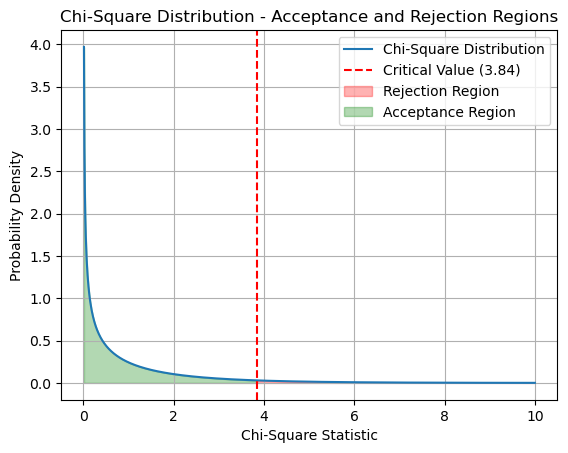

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load the tips dataset (Replace with actual loading method if needed)
from seaborn import load_dataset
tips = load_dataset('tips')

# Step 1: Consider the "sex" column as the population
population_sex = tips['sex']

# Step 2: Draw a random sample
sample_size = 50  # Define sample size
sample_sex = population_sex.sample(n=sample_size, random_state=42)

# Step 3: Calculate observed frequencies
male_count = (sample_sex == 'Male').sum()
female_count = (sample_sex == 'Female').sum()
observed_frequencies = [male_count, female_count]

# Step 4: Define expected frequencies
expected_frequencies = [sample_size / 2, sample_size / 2]  # Equal proportions (50-50 split)

# Step 5: Perform the chi-square goodness-of-fit test
chi_square_statistic, p_value = stats.chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

# Step 6: Print results
alpha = 0.05  # Significance level
df = len(observed_frequencies) - 1  # Degrees of freedom
critical_value = stats.chi2.ppf(1 - alpha, df)  # Critical chi-square value

print(f"Observed Frequencies: {observed_frequencies}")
print(f"Expected Frequencies: {expected_frequencies}")
print(f"Chi-Square Statistic: {chi_square_statistic}")
print(f"P-Value: {p_value}")
print(f"Critical Chi-Square Value: {critical_value}")

if chi_square_statistic > critical_value:
    print("Decision: Reject Null Hypothesis (H0)")
else:
    print("Decision: Fail to Reject Null Hypothesis (H0)")

# Step 7: Plot Chi-Square Distribution and Acceptance/Rejection Regions
x_min, x_max = 0, 10
x = np.linspace(x_min, x_max, 1000)
y = stats.chi2.pdf(x, df)

plt.plot(x, y, label="Chi-Square Distribution")
plt.axvline(x=critical_value, color='red', linestyle='--', label=f"Critical Value ({critical_value:.2f})")
plt.fill_between(x, y, where=(x > critical_value), color='red', alpha=0.3, label="Rejection Region")
plt.fill_between(x, y, where=(x <= critical_value), color='green', alpha=0.3, label="Acceptance Region")
plt.title("Chi-Square Distribution - Acceptance and Rejection Regions")
plt.xlabel("Chi-Square Statistic")
plt.ylabel("Probability Density")
plt.legend(loc="best")
plt.grid()
plt.show()